This notebook is based on the official Documentation and Tutorials of Langchain 🦜🔗.

# Build a Question-Answering System over SQL data


Enabling a LLM system to query structured data can be qualitatively different from unstructured text data. Whereas in the latter it is common to generate text that can be searched against a vector database, the approach for structured data is often for the LLM to write and execute queries in a Domain Specific Language, such as SQL.

In this notebook we'll go over the basic ways to create a Q&A system over tabular data in databases. We will cover implementations using both *chains* and *agents*. These systems will allow us to ask a question about the data in a database and get back a natural language answer. The main difference between the two is that our agent can query the database in a loop as many times as it needs to answer the question.

## Note ⚠️

Building Q&A systems of SQL databases requires executing model-generated SQL queries. There are inherent risks in doing this. Make sure that your database connection permissions are always scoped as narrowly as possible for your chain/agent's needs. This will mitigate however not eliminate the risks of building a model-driven system.

## Architecture

At a high-level, the steps of these systems are:

1. **Convert question to SQL query**: Model converts user input to a SQL query.
2. **Execute SQL query**: Execute the query.
3. **Answer the question**: Model responds to user input using the query results.

Note that querying data in CSVs can follow a similar approach.

![sql_usecase.png](https://github.com/langchain-ai/langchain/blob/master/docs/static/img/sql_usecase.png?raw=1)

## Setup

First, get required packages and set environment variables:

In [1]:
%%capture --no-stderr
%pip install --upgrade --quiet langchain_openai langchain-community langchainhub langgraph

### Sample data

The below example is based on a SQLite connection with the *soccer.sqlite* database, which is a sample database that represents European Soccer database with sqlite3.

Source and short description: https://www.kaggle.com/datasets/hugomathien/soccer?resource=download

Now, `soccer.sqlite` is in our directory and we can interface with it using the SQLAlchemy-driven `SQLDatabase` class:

In [2]:
!curl -L -o ~/soccer.zip\
  https://www.kaggle.com/api/v1/datasets/download/hugomathien/soccer

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 32.7M  100 32.7M    0     0  66.2M      0 --:--:-- --:--:-- --:--:-- 66.2M


In [3]:
!unzip ~/soccer.zip

Archive:  /root/soccer.zip
  inflating: database.sqlite         


In [4]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///database.sqlite")
print(db.dialect)
print(db.get_usable_table_names())
db.run("SELECT * FROM Country LIMIT 10;")

sqlite
['Country', 'League', 'Match', 'Player', 'Player_Attributes', 'Team', 'Team_Attributes']


"[(1, 'Belgium'), (1729, 'England'), (4769, 'France'), (7809, 'Germany'), (10257, 'Italy'), (13274, 'Netherlands'), (15722, 'Poland'), (17642, 'Portugal'), (19694, 'Scotland'), (21518, 'Spain')]"

Great! We've got a SQL database that we can query. Now let's try hooking it up to an LLM.

## Chains

[Chains](https://python.langchain.com/api_reference/langchain/chains.html) are compositions of components / predictable steps like in the example below.

![chain_simple.png](https://www.artefact.com//wp-content/uploads/2024/01/visuel-1-article-medium-langchain.png)

![chain_example.png](https://python.langchain.com/assets/images/tool_chain-3571e7fbc481d648aff93a2630f812ab.svg)


In [LangGraph](https://langchain-ai.github.io/langgraph/concepts/low_level/#multiple-schemas), we can represent a chain via simple sequence of nodes.

Let's create a sequence of steps that, given a question, does the following:
- converts the question into a SQL query;
- executes the query;
- uses the result to answer the original question.


### Application state

The LangGraph [state](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) of our application controls what data is input to the application, transferred between steps, and output by the application. It is typically a `TypedDict`, but can also be a [Pydantic BaseModel](https://langchain-ai.github.io/langgraph/how-tos/state-model/).

For this application, we can just keep track of the input question, generated query, query result, and generated answer:

In [5]:
from typing_extensions import TypedDict


class State(TypedDict):
    question: str
    query: str
    result: str
    answer: str

Now we just need functions that operate on this state and populate its contents.

### Convert question to SQL query

The first step is to take the user input and convert it into a SQL query. To reliably obtain SQL queries (absent markdown formatting and explanations or clarifications), we will make use of LangChain's [structured output](https://python.langchain.com/docs/concepts/structured_outputs/) abstraction.

Let's select a chat model for our application:

In [6]:
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o-mini", model_provider="openai")

Enter API key for OpenAI: ··········


We will pull a prompt from the [Prompt Hub](https://smith.langchain.com/hub) to instruct the model.

In [9]:
from langchain import hub

query_prompt_template = hub.pull("langchain-ai/sql-query-system-prompt")

assert len(query_prompt_template.messages) == 1
query_prompt_template.messages[0].pretty_print()

================================ System Message ================================

Given an input question, create a syntactically correct {dialect} query to run to help find the answer. Unless the user specifies in his question a specific number of examples they wish to obtain, always limit your query to at most {top_k} results. You can order the results by a relevant column to return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Only use the following tables:
{table_info}

Question: {input}


/usr/local/lib/python3.11/dist-packages/langsmith/client.py:253: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


The prompt includes several parameters we will need to populate, such as the SQL dialect and table schemas. LangChain's [SQLDatabase](https://python.langchain.com/api_reference/community/utilities/langchain_community.utilities.sql_database.SQLDatabase.html) object includes methods to help with this. Our `write_query` step will just populate these parameters and prompt a model to generate the SQL query.

In [10]:
from typing_extensions import Annotated


class QueryOutput(TypedDict):
    """Generated SQL query."""

    query: Annotated[str, ..., "Syntactically valid SQL query."]


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result["query"]}

Let's test it out:

In [11]:
write_query({"question": "How many Soccer Players are there?"})

{'query': 'SELECT COUNT(*) as player_count FROM Player;'}

### Execute query

*This is the most dangerous part of creating a SQL chain.* Consider carefully if it is OK to run automated queries over your data. Minimize the database connection permissions as much as possible. Consider adding a human approval step to you chains before query execution (see below).

To execute the query, we will load a tool from [langchain-community](https://python.langchain.com/docs/concepts/architecture/#langchain-community). Our `execute_query` node will just wrap this tool:

In [12]:
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool


def execute_query(state: State):
    """Execute SQL query."""
    execute_query_tool = QuerySQLDatabaseTool(db=db)
    return {"result": execute_query_tool.invoke(state["query"])}

Testing this step:

In [13]:
execute_query({"query": "SELECT COUNT(*) AS player_count FROM Player;"})

{'result': '[(11060,)]'}

### Generate answer

Finally, our last step generates an answer to the question given the information pulled from the database:

In [14]:
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

### Orchestrating with LangGraph

Finally, we compile our application into a single `graph` object. In this case, we are just connecting the three steps into a single sequence.

In [15]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence(
    [write_query, execute_query, generate_answer]
)
graph_builder.add_edge(START, "write_query")
graph = graph_builder.compile()

LangGraph also comes with built-in utilities for visualizing the control flow of your application:

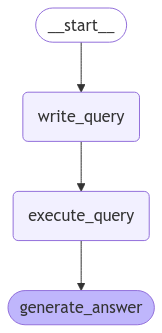

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

Let's test our application! Note that we can stream the results of individual steps:

In [17]:
for step in graph.stream(
    {"question": "How many employees are there?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': 'SELECT COUNT(*) AS employee_count FROM Player;'}}
{'execute_query': {'result': '[(11060,)]'}}
{'generate_answer': {'answer': 'There are 11,060 employees.'}}


### Human-in-the-loop

LangGraph supports a number of features that can be useful for this workflow. One of them is [human-in-the-loop](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/): we can interrupt our application before sensitive steps (such as the execution of a SQL query) for human review. This is enabled by LangGraph's [persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/) layer, which saves run progress to your storage of choice. Below, we specify storage in-memory:

In [18]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory, interrupt_before=["execute_query"])

# Now that we're using persistence, we need to specify a thread ID
# so that we can continue the run after review.
config = {"configurable": {"thread_id": "1"}}

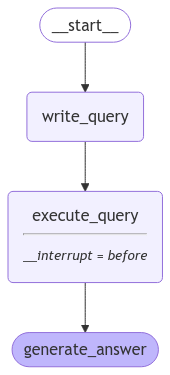

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))

Let's repeat the same run, adding in a simple yes/no approval step:

In [20]:
for step in graph.stream(
    {"question": "How many soccer players are there?"},
    config,
    stream_mode="updates",
):
    print(step)

try:
    user_approval = input("Do you want to go to execute query? (yes/no): ")
except Exception:
    user_approval = "no"

if user_approval.lower() == "yes":
    # If approved, continue the graph execution
    for step in graph.stream(None, config, stream_mode="updates"):
        print(step)
else:
    print("Operation cancelled by user.")

{'write_query': {'query': 'SELECT COUNT(*) AS player_count FROM Player;'}}
{'__interrupt__': ()}
Do you want to go to execute query? (yes/no): yes
{'execute_query': {'result': '[(11060,)]'}}
{'generate_answer': {'answer': 'There are 11,060 soccer players.'}}


See [this](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/) LangGraph guide for more detail and examples.

## Agents

[Agents](https://python.langchain.com/docs/concepts/agents/) leverage the reasoning capabilities of LLMs to make decisions during execution. Using agents allows you to offload additional discretion over the query generation and execution process. Although their behavior is less predictable than the above *Chain*, they feature some advantages:

- They can query the database as many times as needed to answer the user question.
- They can recover from errors by running a generated query, catching the traceback and regenerating it correctly.
- They can answer questions based on the databases' schema as well as on the databases' content (like describing a specific table).

Details: https://python.langchain.com/api_reference/langchain/agents.html

![agent_tools](https://python.langchain.com/assets/images/tool_agent-d25fafc271da3ee950ac1fba59cdf490.svg)

![agent_workflow.png](https://langchain-ai.github.io/langgraph/concepts/img/agent_workflow.png)


Below we assemble a minimal SQL agent. We will equip it with a set of tools using LangChain's [SQLDatabaseToolkit](https://python.langchain.com/api_reference/community/agent_toolkits/langchain_community.agent_toolkits.sql.toolkit.SQLDatabaseToolkit.html).


Using LangGraph's [pre-built ReAct agent constructor](https://langchain-ai.github.io/langgraph/how-tos/#langgraph.prebuilt.chat_agent_executor.create_react_agent), we can do this in one line.

The `SQLDatabaseToolkit` includes tools that can:

* Create and execute queries
* Check query syntax
* Retrieve table descriptions
* ... and more

In [21]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()

tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x79ce81a09250>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x79ce81a09250>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x79ce81a09250>),
 QuerySQLCheckerTool(description='Use this tool to double check

### System Prompt

We will also want to load a system prompt for our agent. This will consist of instructions for how to behave.

In [22]:
from langchain import hub

prompt_template = hub.pull("langchain-ai/sql-agent-system-prompt")

assert len(prompt_template.messages) == 1
prompt_template.messages[0].pretty_print()

================================ System Message ================================

You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to th

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:253: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


Let's populate the parameters highlighted in the prompt:

In [24]:
system_message = prompt_template.format(dialect="SQLite", top_k=5)

### Initializing agent

We will use a prebuilt *LangGraph* agent to build our agent.

In [25]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(llm, tools, prompt=system_message)

Consider how the agent responds to the below question:

In [26]:
question = "Which country's football players won most of the matches?"

for step in agent_executor.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which country's football players won most of the matches?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_j5lyTGx744bApkSWGlRnTmnY)
 Call ID: call_j5lyTGx744bApkSWGlRnTmnY
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Country, League, Match, Player, Player_Attributes, Team, Team_Attributes
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_Dm6NKASCnMsN8wwjmYkvmcmi)
 Call ID: call_Dm6NKASCnMsN8wwjmYkvmcmi
  Args:
    table_names: Country
  sql_db_schema (call_r210ffZbr1qEiDd2KLZ84bmW)
 Call ID: call_r210ffZbr1qEiDd2KLZ84bmW
  Args:
    table_names: Match
  sql_db_schema (call_SRWXSICgsxTt7xBmtAQSXBwk)
 Call ID: call_SRWXSICgsxTt7xBmtAQSXBwk
  Args:
    table_names: Player
=================================


Note that the agent executes multiple queries until it has the information it needs:
1. List available tables;
2. Retrieves the schema for three tables;
3. Queries multiple of the tables via a join operation.

The agent is then able to use the result of the final query to generate an answer to the original question.

The agent can similarly handle qualitative questions:

In [ ]:
question = "Describe the Team_Attributes table"

for step in agent_executor.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Describe the Team_Attributes table
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_kMRgIPskVxnSFjJdkVmNEjQd)
 Call ID: call_kMRgIPskVxnSFjJdkVmNEjQd
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Country, League, Match, Player, Player_Attributes, Team, Team_Attributes
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_vlCfcPXHx07pFFuvD7uctYj7)
 Call ID: call_vlCfcPXHx07pFFuvD7uctYj7
  Args:
    table_names: Team_Attributes
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Team_Attributes" (
	id INTEGER, 
	team_fifa_api_id INTEGER, 
	team_api_id INTEGER, 
	date TEXT, 
	"buildUpPlaySpeed" INTEGER, 
	"buildUpPlaySpeedClass" TEXT, 
	"buildUpPl

### Dealing with high-cardinality columns

In order to filter columns that contain proper nouns such as addresses, song names or artists, we first need to double-check the spelling in order to filter the data correctly.

We can achieve this by creating a vector store with all the distinct proper nouns that exist in the database. We can then have the agent query that vector store each time the user includes a proper noun in their question, to find the correct spelling for that word. In this way, the agent can make sure it understands which entity the user is referring to before building the target query.

First we need the unique values for each entity we want, for which we define a function that parses the result into a list of elements:

In [ ]:
import ast
import re


def query_as_list(db, query):
    res = db.run(query)
    res = [el for sub in ast.literal_eval(res) for el in sub if el]
    res = [re.sub(r"\b\d+\b", "", string).strip() for string in res]
    return list(set(res))


players = query_as_list(db, "SELECT player_name FROM Player")
teams = query_as_list(db, "SELECT team_short_name FROM Team")
players[:5]

['Daniel Follonier',
 'Rafinha',
 'Pablo Chavarria',
 'Chinedu Obasi',
 'Joseph Romeric Lopy']

Using this function, we can create a **retriever tool** that the agent can execute at its discretion.

Let's select an [embeddings model](https://python.langchain.com/docs/integrations/text_embedding/) and [vector store](https://python.langchain.com/docs/integrations/vectorstores/) for this step.

**Select an embedding model**:


In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

**Select a vector store**:


In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

We can now construct a retrieval tool that can search over relevant proper nouns in the database:

In [ ]:
from langchain.agents.agent_toolkits import create_retriever_tool

_ = vector_store.add_texts(players + teams)
retriever = vector_store.as_retriever(search_kwargs={"k": 5})
description = (
    "Use to look up values to filter on. Input is an approximate spelling "
    "of the proper noun, output is valid proper nouns. Use the noun most "
    "similar to the search."
)
retriever_tool = create_retriever_tool(
    retriever,
    name="search_proper_nouns",
    description=description,
)

Let's try it out:

In [ ]:
print(retriever_tool.invoke("Aaron Doran"))

Aaron Doran

Aaron Lennox

Aron Johannsson

Rolando Aarons

Eliran Atar


This way, if the agent determines it needs to write a filter based on the player, it can first use the retriever tool to observe relevant values of a column.

Putting this together:

In [ ]:
# Add to system message
suffix = (
    "If you need to filter on a proper noun like a Name, you must ALWAYS first look up "
    "the filter value using the 'search_proper_nouns' tool! Do not try to "
    "guess at the proper name - use this function to find similar ones."
)

system = f"{system_message}\n\n{suffix}"

tools.append(retriever_tool)

agent = create_react_agent(llm, tools, prompt=system)

In [ ]:
question = "How many players have name Aaron?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

How many players have name Aaron?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_bewclVFG2OD3esLHV5vXG1bm)
 Call ID: call_bewclVFG2OD3esLHV5vXG1bm
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Country, League, Match, Player, Player_Attributes, Team, Team_Attributes
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_N1EZiV8L7aTwLZ2mI5E30XlW)
 Call ID: call_N1EZiV8L7aTwLZ2mI5E30XlW
  Args:
    table_names: Player
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Player" (
	id INTEGER, 
	player_api_id INTEGER, 
	player_name TEXT, 
	player_fifa_api_id INTEGER, 
	birthday TEXT, 
	height INTEGER, 
	weight INTEGER, 
	PRIMARY KEY (id), 
	UNIQUE 